# Python Notebook for Cataloguing and Photometry 

In [2]:
# importing all the relevant libraries 
import numpy as np
import astropy
import astroalign as aa
import photutils
import ccdproc
import os
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_2dg, centroid_sources
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc
gc.enable()

INFO: using the unit adu passed to the FITS reader instead of the unit adu2 in the FITS file. [astropy.nddata.ccddata]
None
Image stats (mean, median and standard deviation): 1.7562355 -3.1149902 24.014729


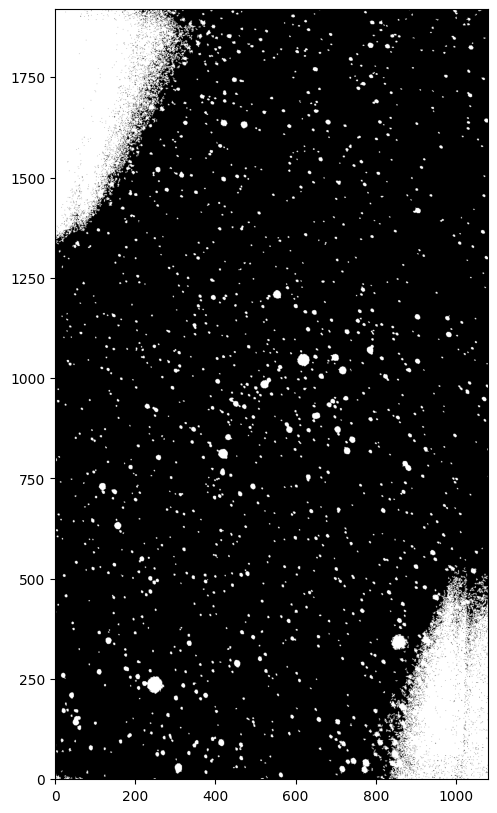

In [21]:
scim=CCDData.read("g_NGC_2547_med.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
# extracting stats cliped at sigma = 3
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 3.0*std, 9, connectivity=4, mask=None) 
# finds and labels bright spots/high adu counts 
# at a threshold of 2 x std in an astronomical image

plt.figure(figsize=(10, 10))
plt.imshow(segimage.data, cmap='gray', vmin=0, vmax=1, origin='lower')

In [ ]:
print(scim.head)

In [5]:
scim.data = scim.data[600:1250][0:-1]

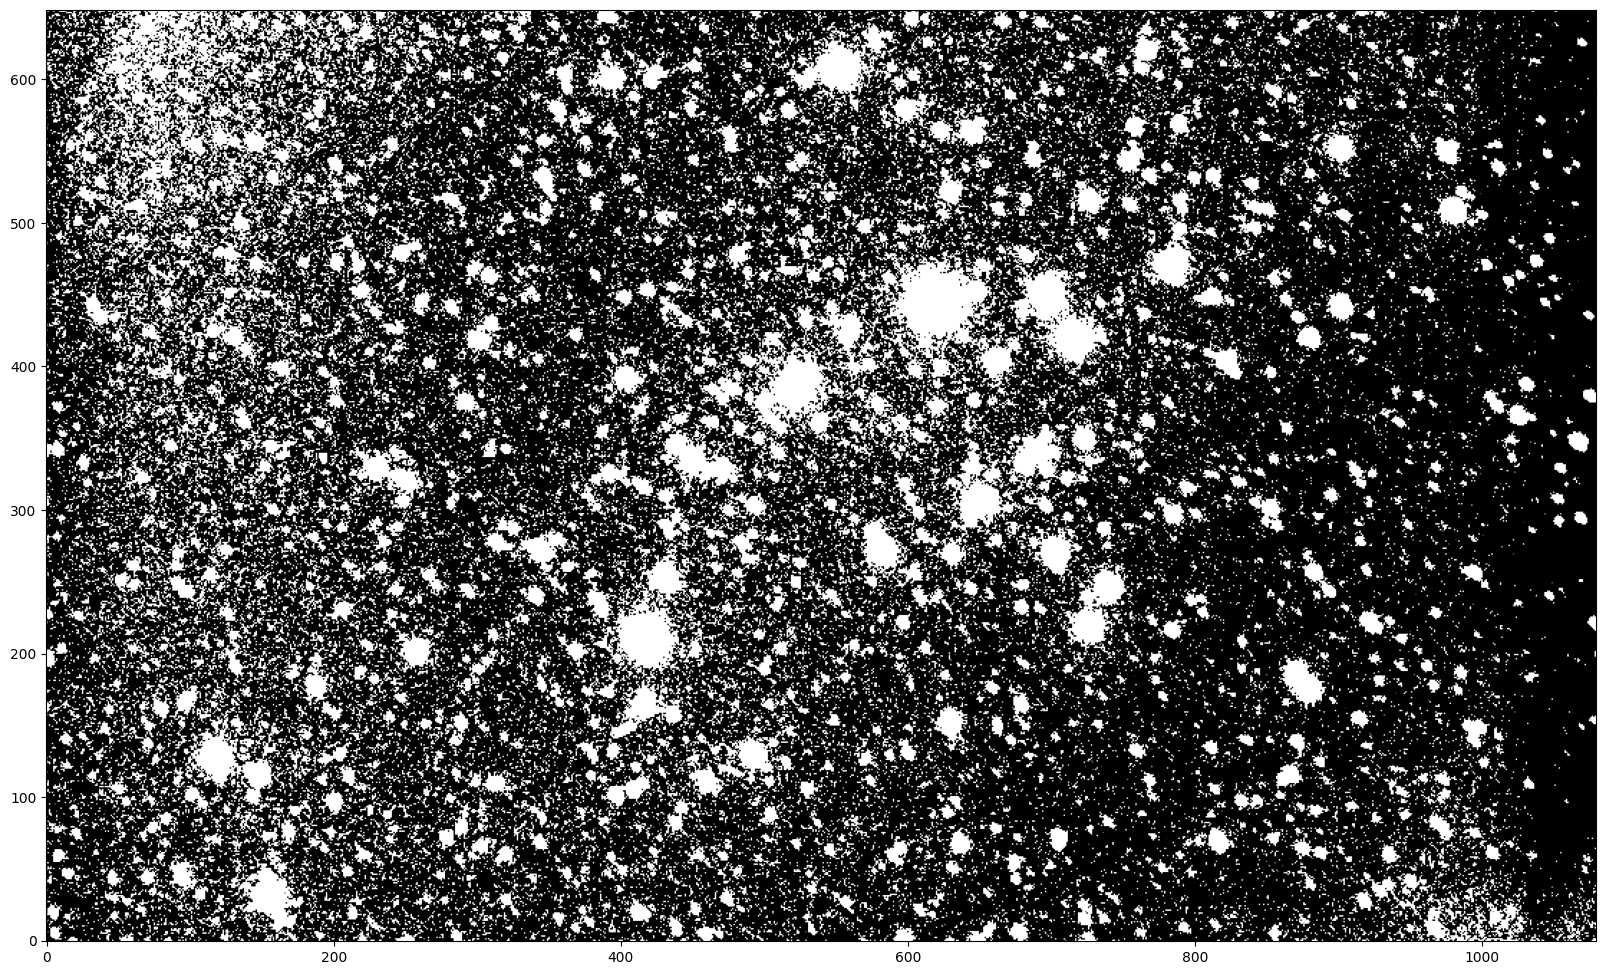

In [6]:
plt.figure(figsize=(20,20))
plt.imshow(scim.data, cmap='gray', vmin=0, vmax=1, origin='lower')

Image stats (mean, median and standard deviation): -0.47763342 -0.86621094 14.150126


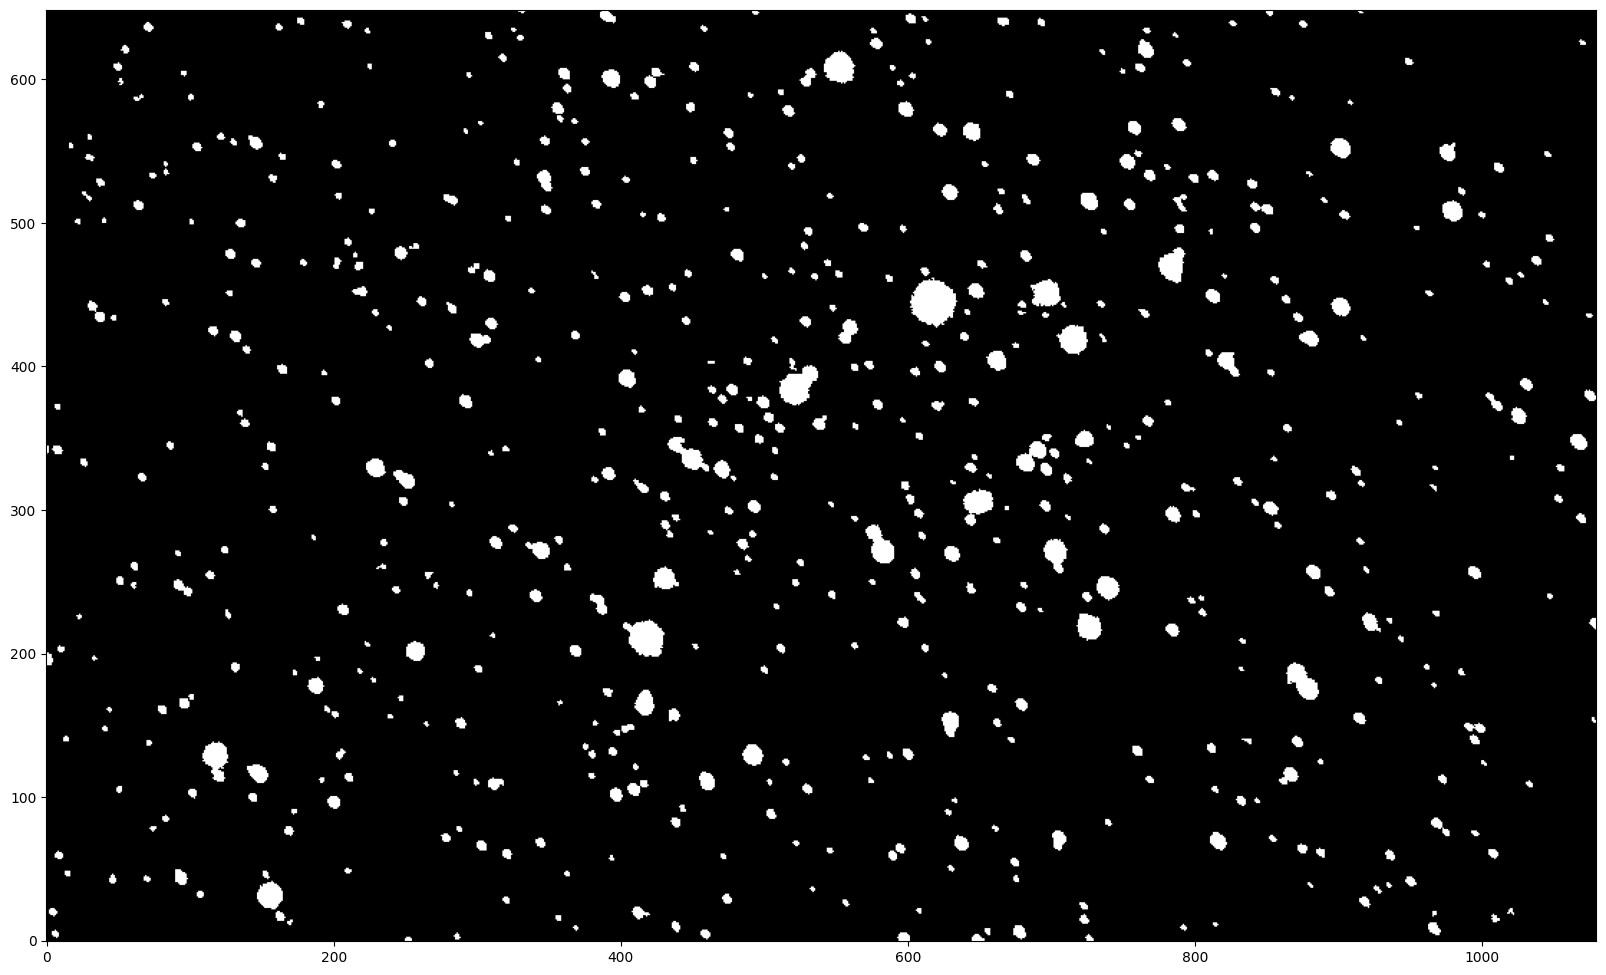

In [11]:
med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
# extracting stats cliped at sigma = 3
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 5.00*std, 9, connectivity=4, mask=None) 
# finds and labels bright spots/high adu counts 
# at a threshold of 2 x std in an astronomical image

plt.figure(figsize=(20,20))
plt.imshow(segimage.data, cmap='gray', vmin=0, vmax=1, origin='lower')